# Project: Salary Dataset Analysis 

### Presented By:    Shaiza Malik

##### email: malikshaiza07@gmail.com

In [2]:
## Import Libraries & Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Load dataset
df = pd.read_csv("Salary Data.csv")

# Display first 5 rows
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


## Data Understanding

### 1. Rows & Columns

In [3]:
df.shape

(375, 6)

### 2. Missing Values

In [4]:
df.isnull()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
370,False,False,False,False,False,False
371,False,False,False,False,False,False
372,False,False,False,False,False,False
373,False,False,False,False,False,False


In [5]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [6]:
df.isnull().sum().sum()

np.int64(12)

### 3. Categorical & Numerical Columns

In [7]:
df.dtypes

Age                    float64
Gender                  object
Education Level         object
Job Title               object
Years of Experience    float64
Salary                 float64
dtype: object

### 4. Mean, Median, Std (Age)

In [10]:
df['Age'].mean()

np.float64(37.43163538873995)

In [9]:
df['Age'].median()

36.0

In [11]:
df['Age'].std()

7.069072938567496

### 5. Gender Proportion

In [13]:
df['Gender'].value_counts(normalize=True) * 100

Gender
Male      52.010724
Female    47.989276
Name: proportion, dtype: float64

### 6. Education Levels

In [14]:
df['Education Level'].value_counts(normalize=True) * 100

Education Level
Bachelor's    60.053619
Master's      26.273458
PhD           13.672922
Name: proportion, dtype: float64

## Data Cleaning & Preprocessing

### 7. Rows with all NaN

In [15]:
df.isnull().all(axis=1).sum()

np.int64(2)

In [ ]:
## Missing values handles

In [16]:
df = df.dropna(how='all')

### 8. Duplicate Rows

In [17]:
df.duplicated().sum()

np.int64(49)

In [19]:
## Remove duplicate rows

df = df.drop_duplicates()                   ## Duplicates Overfitting increase hota hai

### 9. Reset Index

In [20]:
df.reset_index(drop=True, inplace=True)

### 10. Encoding Categorical Variables

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['Education Level'] = le.fit_transform(df['Education Level'])
df['Job Title'] = le.fit_transform(df['Job Title'])

## Exploratory Data Analysis

### 11. Age Distribution

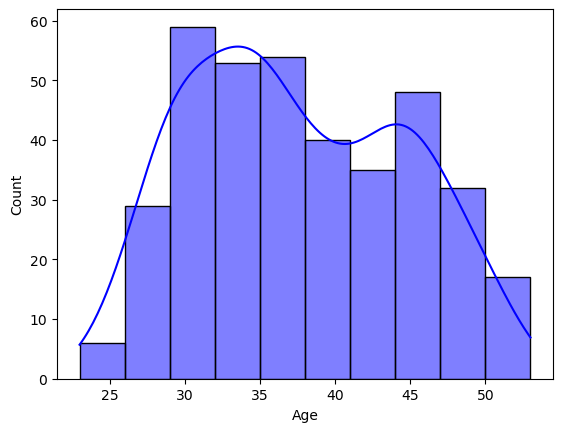

In [4]:
sns.histplot(df['Age'], kde=True, color= 'blue')
plt.show()

**This histogram shows Slightly normal distribution, Minor skew possible**

### 12. Experience Distribution

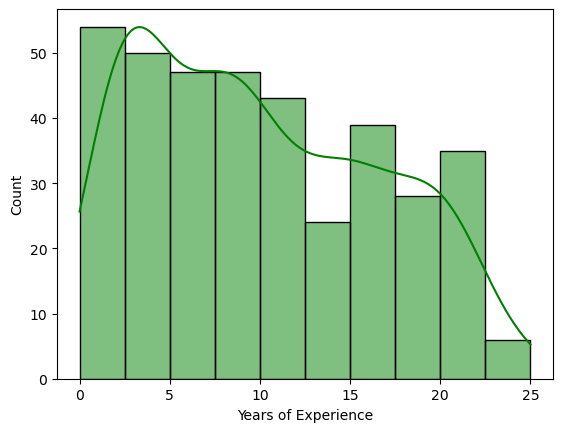

In [5]:
sns.histplot(df['Years of Experience'], kde=True, color='green')
plt.show()

**This histogram shows most employees are in mid-level experience.**

### 13. Salary vs Education

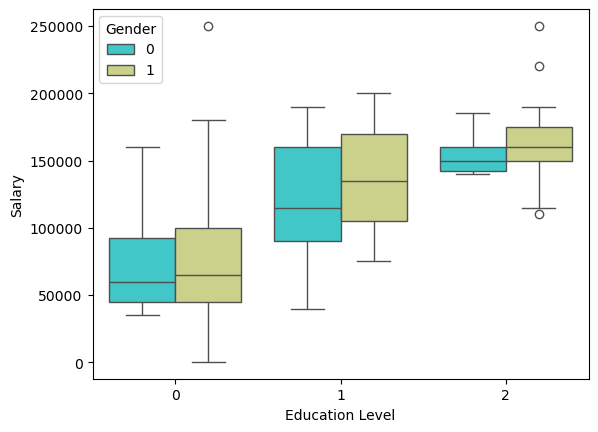

In [29]:
sns.boxplot(x='Education Level',y='Salary',hue='Gender',data=df,palette='rainbow')
plt.show()

**This Boxplot shows genderwise that higher education → higher salary trend.**

### 14. Avg Salary by Gender

In [30]:
df.groupby('Gender')['Salary'].mean()

Gender
0     96136.363636
1    103472.647059
Name: Salary, dtype: float64

### 15. Education vs Salary

In [31]:
df.groupby('Education Level')['Salary'].mean()

Education Level
0     73902.356021
1    127912.087912
2    158095.238095
Name: Salary, dtype: float64

In [ ]:
## Education positively impacts salary

### 16. Experience Categories

In [33]:
bins = [0,5,10,15,20,100]
labels = ['0-5','6-10','11-15','16-20','20+']

df['Exp Category'] = pd.cut(df['Years of Experience'], bins=bins, labels=labels)

df.groupby('Exp Category', observed=True)['Salary'].mean()

Exp Category
0-5       49330.288462
6-10      92215.189873
11-15    115178.571429
16-20    158684.210526
20+      175400.000000
Name: Salary, dtype: float64

## Correlation

### 17. Heatmap

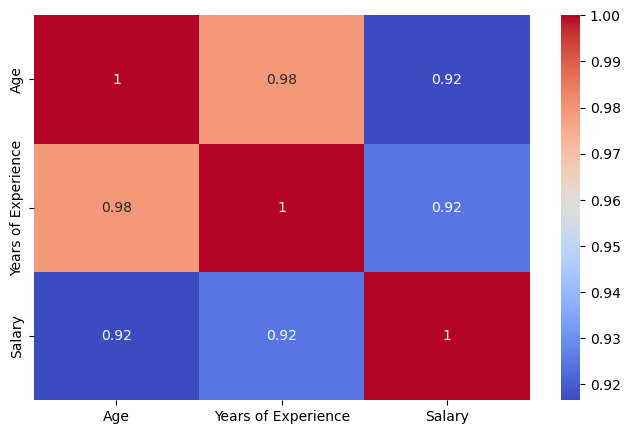

In [35]:
plt.figure(figsize=(8,5))
sns.heatmap(
    df[['Age', 'Years of Experience', 'Salary']].corr(),annot=True,cmap='coolwarm')
plt.show()

**This heatmap shows Experience strongly correlated with Salary**

### 18. Scatter Matrix

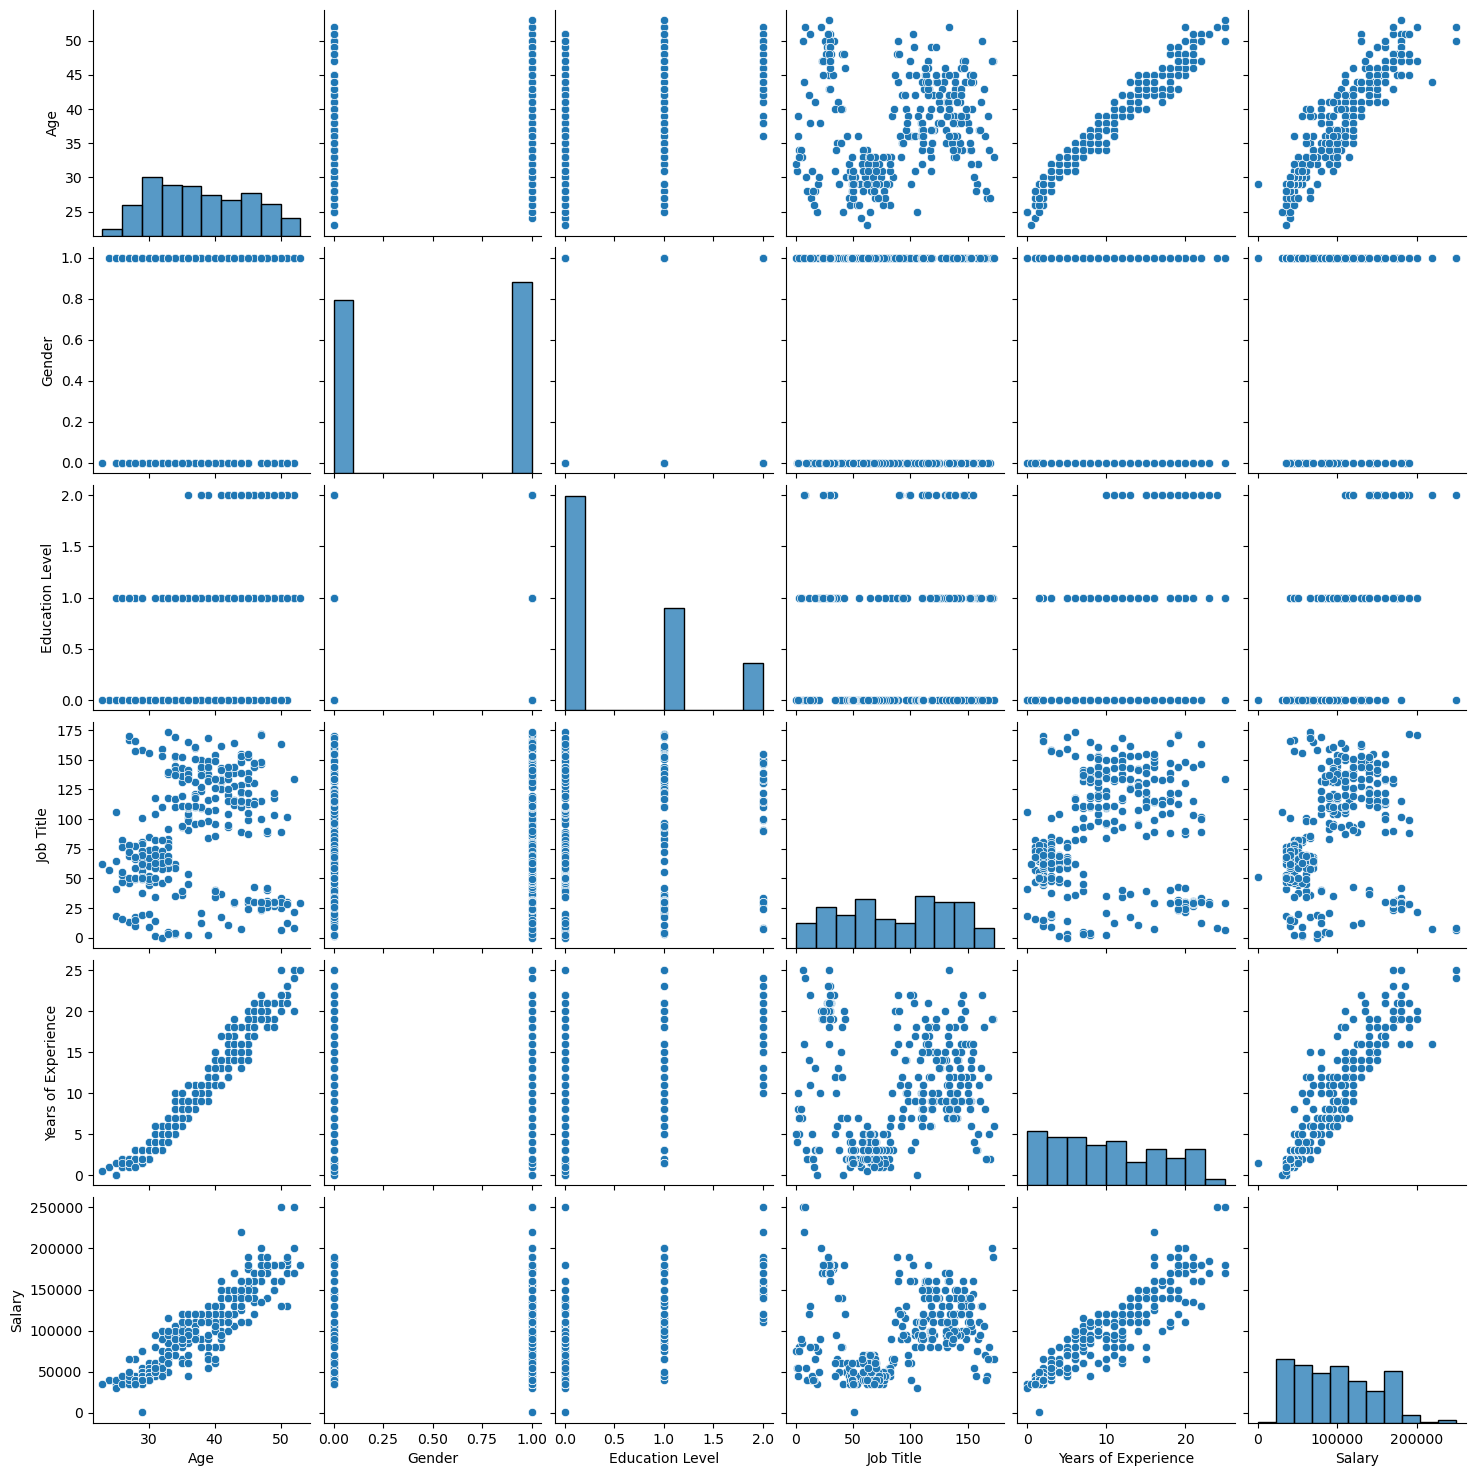

In [36]:
sns.pairplot(df)
plt.show()

## Model Building

### 19. Features & Target

In [47]:
df = df.dropna()
X = df.drop(['Salary', 'Exp Category'], axis=1)
y = df['Salary']

### 20. Train-Test Split

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 21. Algorithm (Linear Regression)

In [49]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


**Linear Regression used for Continuous target (Salary)**

### 22. Training Score

In [50]:
model.score(X_train, y_train)

0.8943412857654673

## Evaluation

### 23. R² Score

In [51]:
y_pred = model.predict(X_test)

from sklearn.metrics import r2_score

r2_score(y_test, y_pred)

0.8863252111804133

### 24. RootMeanSquareError

In [52]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse

np.float64(15657.699719991111)

**Lower RMSE = better**

### Predicted vs Actual

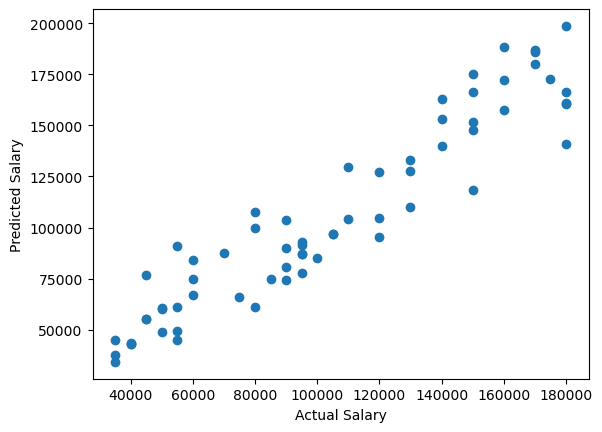

In [53]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.show()

**Points near line → good model**

## Critical Thinking 

### Important Features
**Years of Experience (strong impact)**

**Education Level**

**Job Title**

### Important Preprocessing
**Missing value handling**

**Encoding categorical variables**

**Removing duplicates**

### Improvements
**Feature engineering**
  
**Try Random Forest / XGBoost**

**Hyperparameter tuning**

**Outlier removal**